In [1]:
import os
import sys
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import geopandas as gp
import arviz as az
import matplotlib.colors as mcolors


In [3]:
cd ../

In [4]:
sys.path.insert(0, './src/')
from plot.odds_ratios import *

In [5]:
idata_soc = az.from_netcdf('./idata/ew/rsv_intent_ord_soc_wo_micro.nc')
with open('./dat/dat_for_inference/ew/var_mappings_ord_wo_poststrat.p', 'rb') as f:
    var_mappings_soc = pickle.load(f)
with open('./dat/dat_for_inference/ew/data_dict_ord_wo_poststrat.p', 'rb') as f:
    data_dict_soc = pickle.load(f)
survey_soc = pd.read_csv('./dat/dat_for_inference/ew/survey_ord_wo_poststrat.tsv', sep = '\t', index_col = 0)

In [6]:
idata_bes = az.from_netcdf('./idata/ew/rsv_intent_besd_soc.nc')
with open('./dat/dat_for_inference/ew/var_mappings_besd_soc.p', 'rb') as f:
    var_mappings_bes = pickle.load(f)
with open('./dat/dat_for_inference/ew/data_dict_besd_soc.p', 'rb') as f:
    data_dict_bes = pickle.load(f)
survey_bes = pd.read_csv('./dat/dat_for_inference/ew/survey_besd_soc.tsv', sep = '\t', index_col = 0)

besd_ord = [f'besd{i}' for i in [1,2,3,14,15,17]]
besd_ber = [f'besd{i}' for i in [4,5,8,9,10,11,12,13]]
besd_cat = [f'besd{i}' for i in [6,7]]
besd_vars = besd_ord + besd_ber + besd_cat

import xarray as xr

posterior = idata_bes.posterior

for i, var_name in enumerate(besd_ord):
    var_data = posterior['beta_besd_ord'].values[:, :, i, :]
    new_var = xr.DataArray(var_data, 
    dims=["chain", "draw", "dim_0"], 
    coords={"chain": posterior.chain, "draw": posterior.draw})
    posterior[f'beta_{var_name}'] = new_var

for i, var_name in enumerate(besd_ber):
    var_data = posterior['beta_besd_ber'].values[:, :, i]

    # Create a new DataArray for the variable
    new_var = xr.DataArray(var_data, 
    dims=["chain", "draw"], 
    coords={"chain": posterior.chain, "draw": posterior.draw})
    
    # Add the new variable to the posterior group
    posterior[f'beta_{var_name}'] = new_var

idata_bes.posterior = posterior

In [7]:
recode_mapping_reverse = var_mappings_bes['recode_mapping_reverse']

rename_mapping_for_plot = {}

recode_mapping_for_plot = recode_mapping_reverse.copy()

value_mapping = {}

value_mapping['ETH'] = {
    'White: English, Welsh, Scottish, Northern Irish or British': 'White: British',
    'White: Irish': 'White: Irish',
    'Arab': 'Arab',
    'White: Other White': 'White: Other White',
    'Mixed or Multiple ethnic groups: White and Asian': 'Mixed: White and Asian',
    'Black, Black British, Black Welsh, Caribbean or African: Other Black': 'B,BB,BW: Other Black',
    'Asian, Asian British or Asian Welsh: Chinese': 'A,AB,AW: Chinese',
    'Black, Black British, Black Welsh, Caribbean or African: Caribbean': 'B,BB,BW: Caribbean',
    'Mixed or Multiple ethnic groups: White and Black African': 'Mixed: White and Black African',
    'Asian, Asian British or Asian Welsh: Pakistani': 'A,AB,AW: Pakistani',
    'Black, Black British, Black Welsh, Caribbean or African: African': 'B,BB,BW: African',
    'Other': 'Other ethnic group',
    'Asian, Asian British or Asian Welsh: Other Asian': 'A,AB,AW: Other Asian',
    'Asian, Asian British or Asian Welsh: Indian': 'A,AB,AW: Indian',
    'Asian, Asian British or Asian Welsh: Bangladeshi': 'A,AB,AW: Bangladeshi',
    'Mixed or Multiple ethnic groups: White and Black Caribbean': 'Mixed: White,Black',
    'Prefer not to say' : 'Prefer not to say',
}

value_mapping['LAN'] = {
    'English (English or Welsh in Wales)': 'English',
    'Other': 'Other',
    'Urdu': 'Urdu',
    'Polish': 'Polish',
    'Romanian': 'Romanian',
    'Punjabi': 'Punjabi'
}

value_mapping['EDU'] = {
    '2 or more A levels or VCEs, 4 or more AS levels, Higher School Certificate, Progression or Advanced Diploma, Welsh Baccalaureate Advance Diploma, NVQ level 3; Advanced GNVQ, City and Guilds Advanced Craft, ONC, OND, BTEC National, RSA Advanced Diploma': 'level-3',
    
    '5 or more GCSEs (A* to C or 9 to 4), O levels (passes), CSEs (grade 1), School Certification, 1 A level, 2 to 3 AS levels, VCEs, Intermediate or Higher Diploma, Welsh Baccalaureate Intermediate Diploma, NVQ level 2, Intermediate GNVQ, City and Guilds Craft, BTEC First or General Diploma, RSA Diploma': 'level-2',

    'No qualifications': 'level-0',

    'Degree (BA, BSc), higher degree (MA, PhD, PGCE), NVQ level 4 to 5, HNC, HND, RSA Higher Diploma, BTEC Higher level, professional qualifications (for example, teaching, nursing, accountancy)': 'level-4',

    '1 to 4 GCSEs grade A* to C, Any GCSEs at other grades, O levels or CSEs (any grades), 1 AS level, NVQ level 1, Foundation GNVQ, Basic or Essential Skills': 'level-1',

    'Other: apprenticeships, vocational or work-related qualifications, other qualifications achieved in England or Wales, qualifications achieved outside England or Wales': 'Other'
}


value_mapping['EMP'] = {
    'Working part or full-time (including self-employed, excluding students)': 'Working',
    
    'Economically inactive: Long-term sick or disabled': 'Long-term sick',

    'Economically inactive: Looking after home or family': 'Looking after home',

    'Economically active (excluding full-time students): Unemployed: Seeking work or waiting to start a job already obtained: Available to start working within 2 weeks': 'Seeking work',

    'Economically active and full-time student: In employment': 'Student, employed',

    'Economically inactive: Retired': 'Retired',

    'Economically inactive: Other': 'Inactive other',

    'Economically inactive: Student': 'Student, inactive',

    'Economically active and a full-time student: Unemployed: Seeking work or waiting to start a job already obtained: Available to start working within 2 weeks': 'Student, unemployed'
}


value_mapping['HHLAN'] = {
    'No people in my household have English or Welsh as their main language': 'No',
    
    'Yes, at least one person in my household has English or Welsh as their main language': 'Yes'
}

value_mapping['DIS'] = {
    'Not disabled under the Equality Act': 'Not disabled',
    
    'Disabled under the Equality Act: Day-to-day activities limited a little': 'Disabled:\nlimited a little',
    
    'Disabled under the Equality Act: Day-to-day activities limited a lot': 'Disabled:\nlimited a lot'
}


for _var, _mapping in value_mapping.items():
    new_dict = recode_mapping_for_plot[_var].copy()
    new_dict = { k : _mapping[v] for k,v in new_dict.items() }
    recode_mapping_for_plot[_var] = new_dict.copy()

for k in recode_mapping_for_plot:
    rename_mapping_for_plot[k] = { v : recode_mapping_for_plot[k][i] for i,v in recode_mapping_reverse[k].items()}


for k,d in rename_mapping_for_plot.items():
    if k in survey_bes.columns:
        survey_bes[k] = survey_bes[k].map(d)
    if k in survey_soc.columns:
        survey_soc[k] = survey_soc[k].map(d)

soc_dems = ['AGE', 'SEX', 'EDU', 'REL', 'ETH', 'LAN', 'HHLAN', 'MIG', 'BUK', 'YUK', 'HEA', 'SCH', 'DIS', 'ENP', 'EMP']

In [8]:
alpha_besd_backgound = 0.45
alpha_violin_plot_soc = 0.7
alpha_violin_plot_besd = 0.7

In [9]:

# yellow
_thinking_and_feeling = {'besd1': 'How important do you think vaccines are for your children’s health', 
                        'besd2': 'How safe do you think vaccines are for your children?',
                        'besd3' : 'How much do you trust the health workers who given children vaccines?'}
# green
_social_processes = {'besd4' : 'Do you think most parents you know get their children vaccinated?', 
                    'besd5' : 'Do you think most of your close family and friends want you to get your children vaccinated?',
                    'besd6' : ' Do you think your religious leaders want you to get your children vaccinated?',
                    'besd7' : 'Do you think your community leaders want you to get your children vaccinated?',
                    'besd8' : 'Has a health worker recommended your children be vaccinated?',
                    'besd9' : 'Have you ever been contacted about your children being due for vaccination?'}
# red
_motivation = {}
# blue
_practical_issues = {'besd10' : 'If it was time for your child to get vaccinated, would the mother need permission to take the child to the clinic?',
                    'besd11' : 'Do you know where to go to get your child vaccinated?',
                    'besd12' : 'Have you personally ever taken your child/children to get vaccinated?',
                    'besd13' : 'Have you ever been turned away when you tried to get your children vaccinated?',
                    'besd14' : 'How easy is it to get vaccination services for your children',
                    'besd15' : 'How easy is it to pay for vaccination? When you think about the cost, please consider any payments to the clinic, the cost of getting there, plus the cost of taking time away from work',
                    'besd17' : 'How satisfied are you with the vaccination services in the UK?'}

_thinking_and_feeling_description = {'besd1': 'Vaccines and children’s health', 
                        'besd2': 'Vaccines safe for children',
                        'besd3' : 'Trust in health workers who vaccinate'}
# green
_social_processes_description = {'besd4' : 'Most parents vaccinate their children', 
                    'besd5' : 'Family and friends want me to vaccinate',
                    'besd6' : 'Religious leaders want me to vaccinate',
                    'besd7' : 'Community leaders want me to vaccinate',
                    'besd8' : 'Health worker recommended vaccination?',
                    'besd9' : 'Have been contacted about vaccination'}
# red
_motivation_description = {}
# blue
_practical_issues_description = {'besd10' : 'Mother needs permission for clinic',
                    'besd11' : 'Know where to get child vaccinated',
                    'besd12' : 'Personally took child to vaccination',
                    'besd13' : 'Was turned away from vaccination',
                    'besd14' : 'How easy to get vaccination',
                    'besd15' : 'How easy to pay for vaccination',
                    'besd17' : 'How satisfied with vaccination services'}


thinking_and_feeling = list(_thinking_and_feeling.keys())
social_processes = list(_social_processes.keys())
motivation = list(_motivation.keys())
practical_issues = list(_practical_issues.keys())

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4))


_colors_besd  = {
'thinking_and_feeling' :  (*hex_to_rgb('#fbe7a3'), alpha_besd_backgound), # yellow
'social_processes': (*hex_to_rgb('#c9dfb9'), alpha_besd_backgound), # green
'motivation': (*hex_to_rgb('#f2b0ac'), alpha_besd_backgound), # red
'practical_issues': (*hex_to_rgb('#9fbee2'), alpha_besd_backgound) #blue
}

colors_besd = { b : _colors_besd['thinking_and_feeling'] for b in thinking_and_feeling}
colors_besd.update(  { b : _colors_besd['social_processes'] for b in social_processes} )
colors_besd.update(  { b : _colors_besd['practical_issues'] for b in practical_issues} )
colors_besd.update(  { b : _colors_besd['motivation'] for b in motivation} )

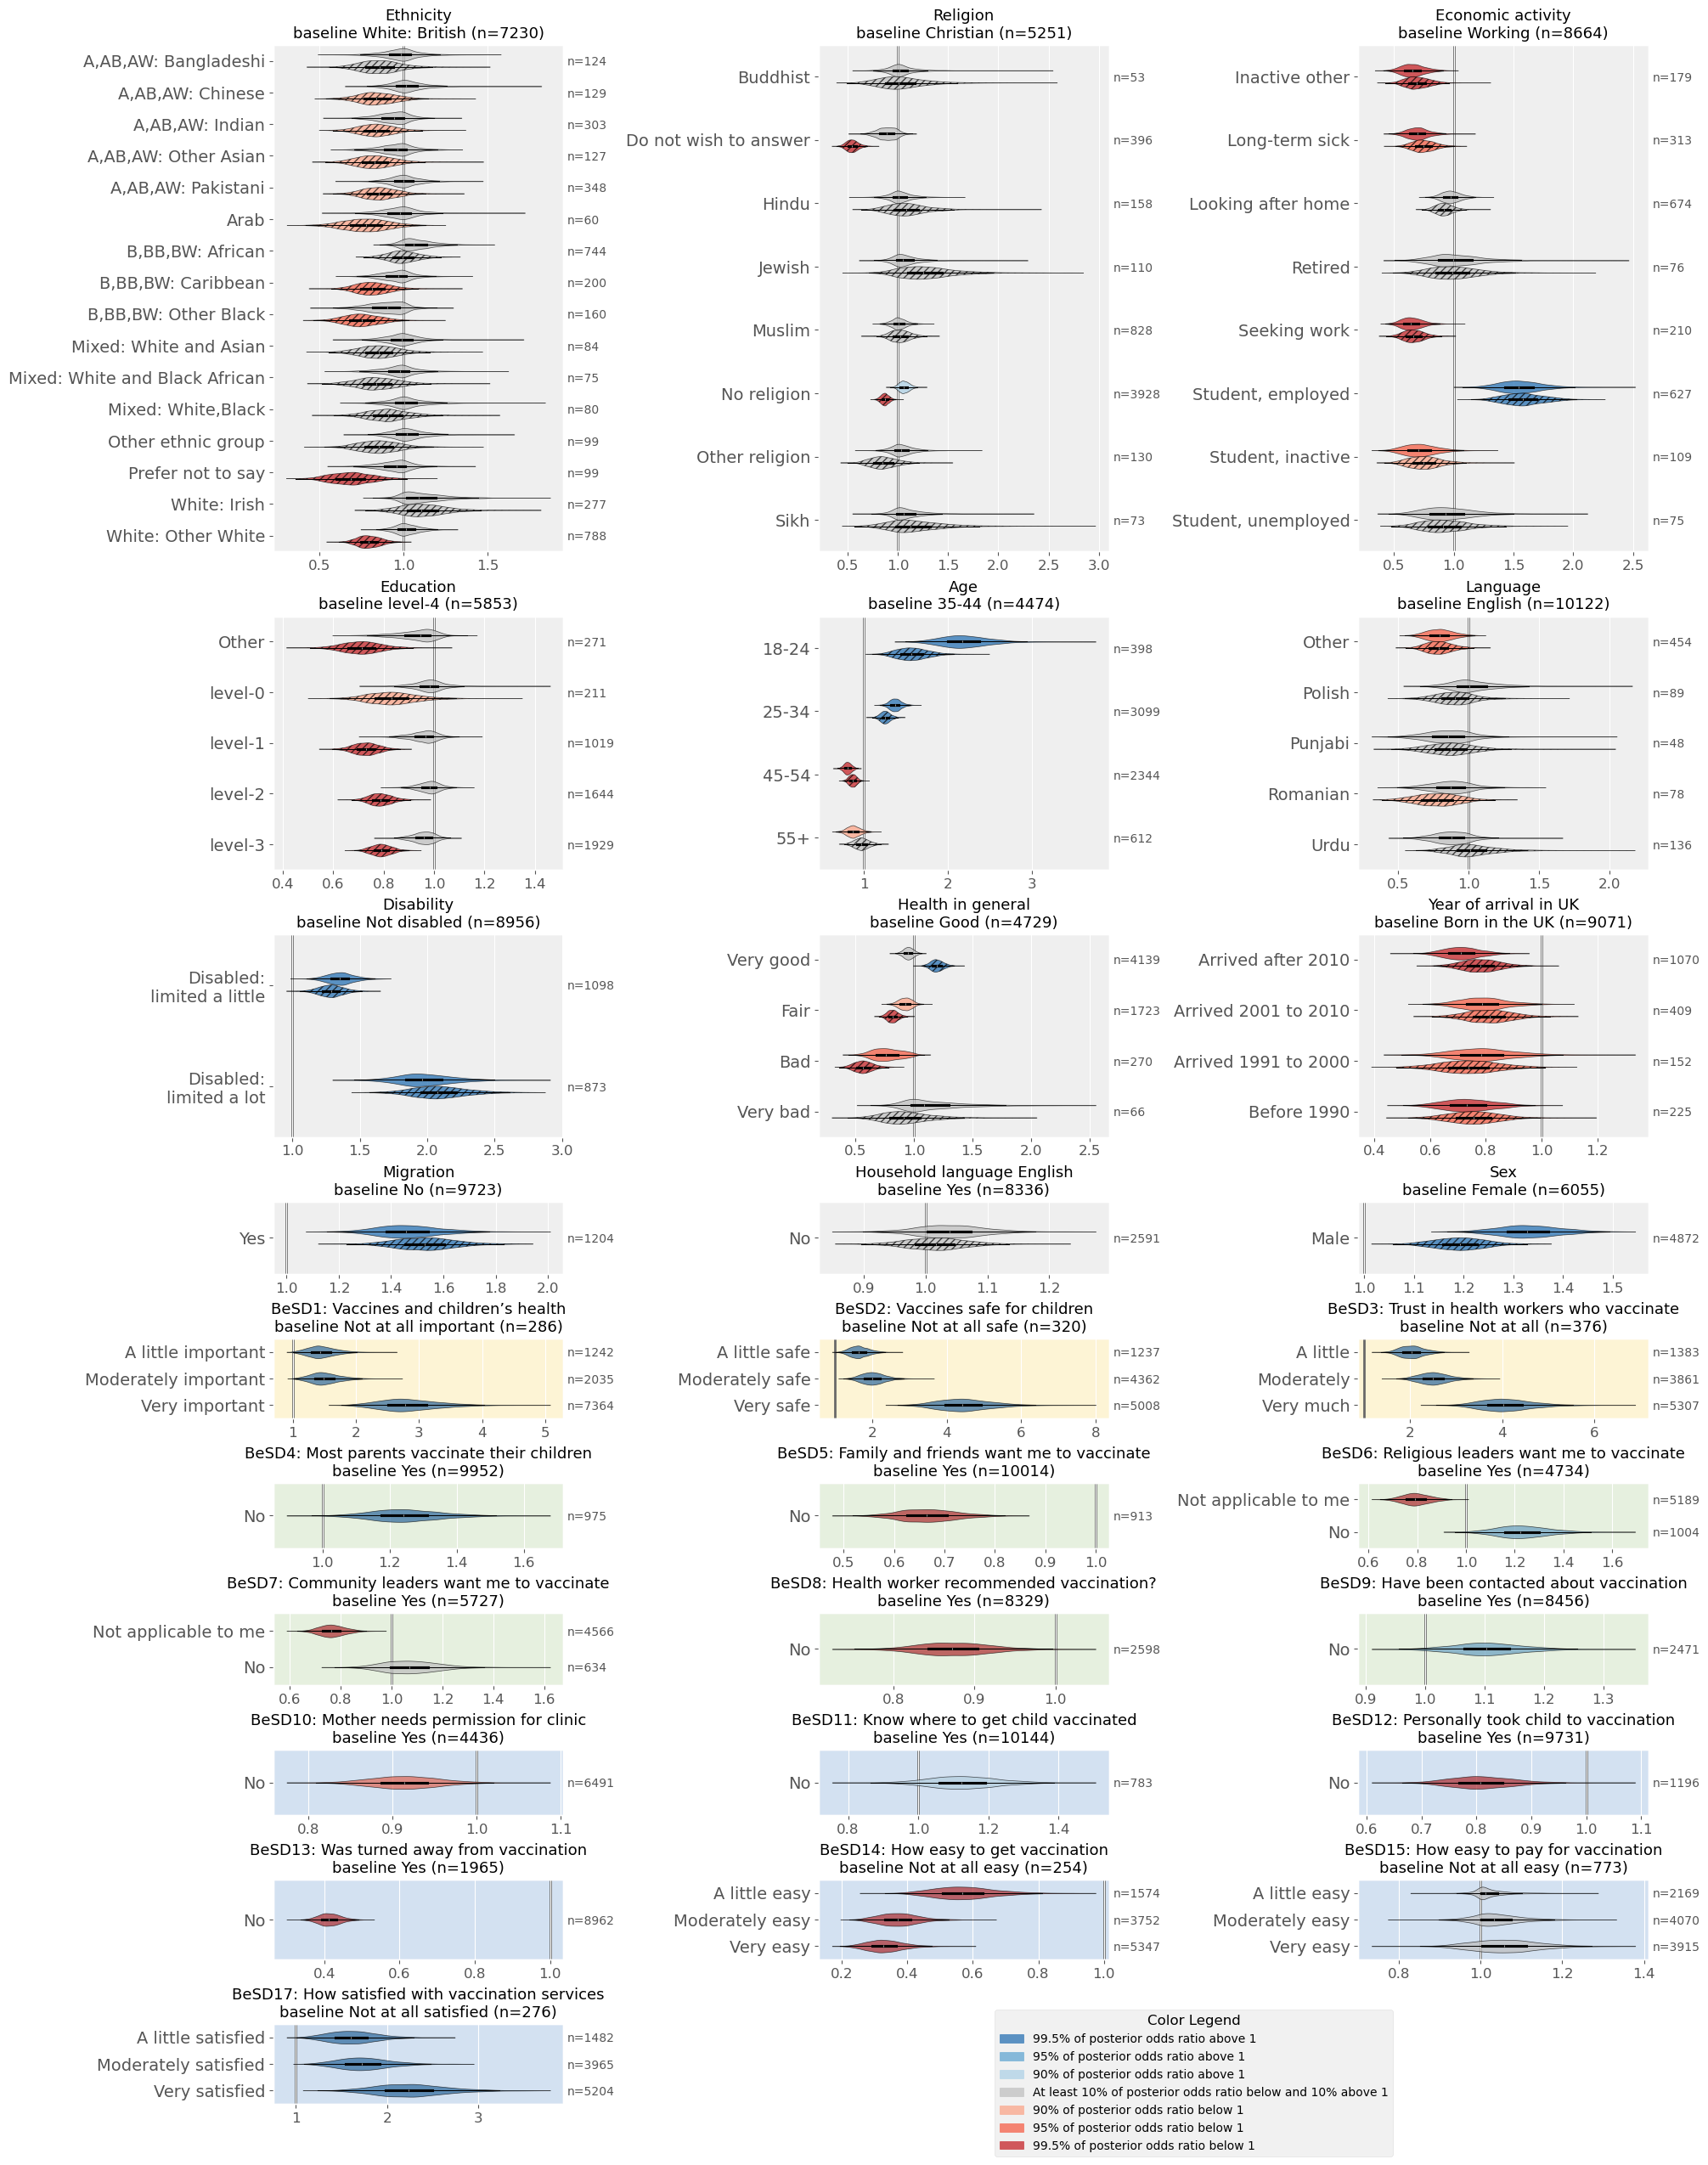

In [10]:
import matplotlib.colors as mcolors


title_var_names = {'AGE': 'Age',
 'SEX': 'Sex',
 'EDU': 'Education',
 'REL': 'Religion',
 'ETH': 'Ethnicity',
 'LAN': 'Language',
 'HHLAN': 'Household language English',
 'MIG': 'Migration',
 'BUK': 'Born in the UK',
 'YUK': 'Year of arrival in UK',
 'HEA': 'Health in general',#'Fair',
 'SCH': 'No',
 'DIS': 'Disability',
 'ENP': 'Enlgish proficieny',
 'EMP': 'Economic activity',}

title_var_names.update(_thinking_and_feeling_description)
title_var_names.update(_social_processes_description)
title_var_names.update(_practical_issues_description)

alpha_besd_backgound = 0.45


baselines = {'AGE': '35-44',
 'SEX': 'Female',
 'EDU': 'level-4',
 'REL': 'Christian',
 'ETH': 'White: British',
 'LAN': 'English',
 'HHLAN': 'Yes',
 'MIG': 'No',
 'BUK': 'Yes',
 'YUK': 'Born in the UK',
 'HEA': 'Good',#'Fair',
 'SCH': 'No',
 'DIS': 'Not disabled',
 'ENP': 'Main language English',
 'EMP': 'Working',
 'besd6' : 'Yes',
 'besd7' : 'Yes',
}

for b in besd_ber:
    baselines[b] = 'Yes'

for b in besd_ord:
    baselines[b] = recode_mapping_reverse[b][0]

plt.style.use('ggplot')

orderd_labels_dict = {}
for var_name in ['ETH','REL','LAN','EMP','EDU','AGE']:
    orderd_labels_dict[var_name] = list( np.sort( list( recode_mapping_for_plot[var_name].values() ) ) )

orderd_labels_dict['YUK'] = ['Born in the UK', 'Arrived after 2010', 'Arrived 2001 to 2010', 'Arrived 1991 to 2000', 'Before 1990' ]
orderd_labels_dict['HEA'] = ['Very good', 'Good', 'Fair', 'Bad', 'Very bad']
orderd_labels_dict['DIS'] = ['Not disabled', 'Disabled:\nlimited a little', 'Disabled:\nlimited a lot']

soc_scale = 2
height_ratios = [7*soc_scale, 3.5*soc_scale, 2.8*soc_scale, 1.0*soc_scale, 2.2, 1.8, 2, 1.8, 2.2, 2.2]#[3]*10

fig, axes = plt.subplots(10,3, figsize = (20,25), constrained_layout = True, height_ratios = height_ratios )
for k, (var_name, coef_name) in enumerate( zip(['ETH','REL','EMP', 'EDU','AGE','LAN','DIS','HEA','YUK','MIG','HHLAN','SEX'] + thinking_and_feeling + social_processes + practical_issues,#'SCH'
                                              ['beta_eth', 'beta_rel', 'beta_emp', 'beta_edu', 'beta_age', 'beta_lan', 'beta_dis', 'beta_hea', 'beta_yuk','beta_mig', 'beta_hhlan', 'beta_sex']
                                              + [f'beta_{b}' for b in thinking_and_feeling] + [f'beta_{b}' for b in social_processes] + [f'beta_{b}' for b in practical_issues]) #, 'beta_sch'])
                                         ):
    i,j = k //3, k%3
    ax = axes[i,j]
    h_ratio = height_ratios[i]
    if var_name in soc_dems:
        h_ratio = 1 * h_ratio / soc_scale
    num_violin_plots = len(recode_mapping_reverse[var_name].values()) - 1
    
    if var_name in thinking_and_feeling + social_processes + practical_issues:
        alpha = alpha_violin_plot_besd # 0.85
        _besd_i = 'BeSD' + var_name.strip('besd')
        _title = f'{_besd_i}: {title_var_names[var_name]}\nbaseline {baselines[var_name]}'
    else:
        alpha =alpha_violin_plot_soc #  0.85
        _title = f'{title_var_names[var_name]}\nbaseline {baselines[var_name]}'
    plot_odds_ratio_bes_soc(idata_bes = idata_bes, idata_soc = idata_soc, soc_dems = soc_dems, ax = ax, recode_mapping_reverse = recode_mapping_for_plot, coef_name = coef_name, var_name = var_name, title = _title, num_samples = 2000, 
                    plot_type = 'violin', violin_width = 0.35*(num_violin_plots/h_ratio), max_len_label = 30, baseline = baselines[var_name], survey = survey_bes.copy(), add_n = True, # palette = palette,
                    alpha = alpha, orderd_labels_dict = orderd_labels_dict, title_size = 13,
                    hatch_width = 1.0, hatch_symbol = '////', hatch_color = 'black',
                    )
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=12)

    if var_name in soc_dems:
        ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_besd_backgound) )
    if var_name in thinking_and_feeling:
        ax.patch.set_facecolor( _colors_besd['thinking_and_feeling'])
    if var_name in social_processes:
        ax.patch.set_facecolor( _colors_besd['social_processes'])
    if var_name in practical_issues:
        ax.patch.set_facecolor( _colors_besd['practical_issues'])
    ax.set_xlabel('')
    ax.set_ylabel('')
for k in [28,29]:
    i,j = k //3, k%3
    ax = axes[i,j]
    ax.remove()

add_custom_legend(fig, anchor_x = 0.7, anchor_y = -0.02, framealpha = 0.5, fontsize=10, title_fontsize=12, # palette = palette,
                  alpha = alpha_violin_plot_soc ) # 0.85)

fig.savefig('./fig/ew/besd_soc_hatch_odds_ratio.jpg', dpi = 200, bbox_inches='tight')

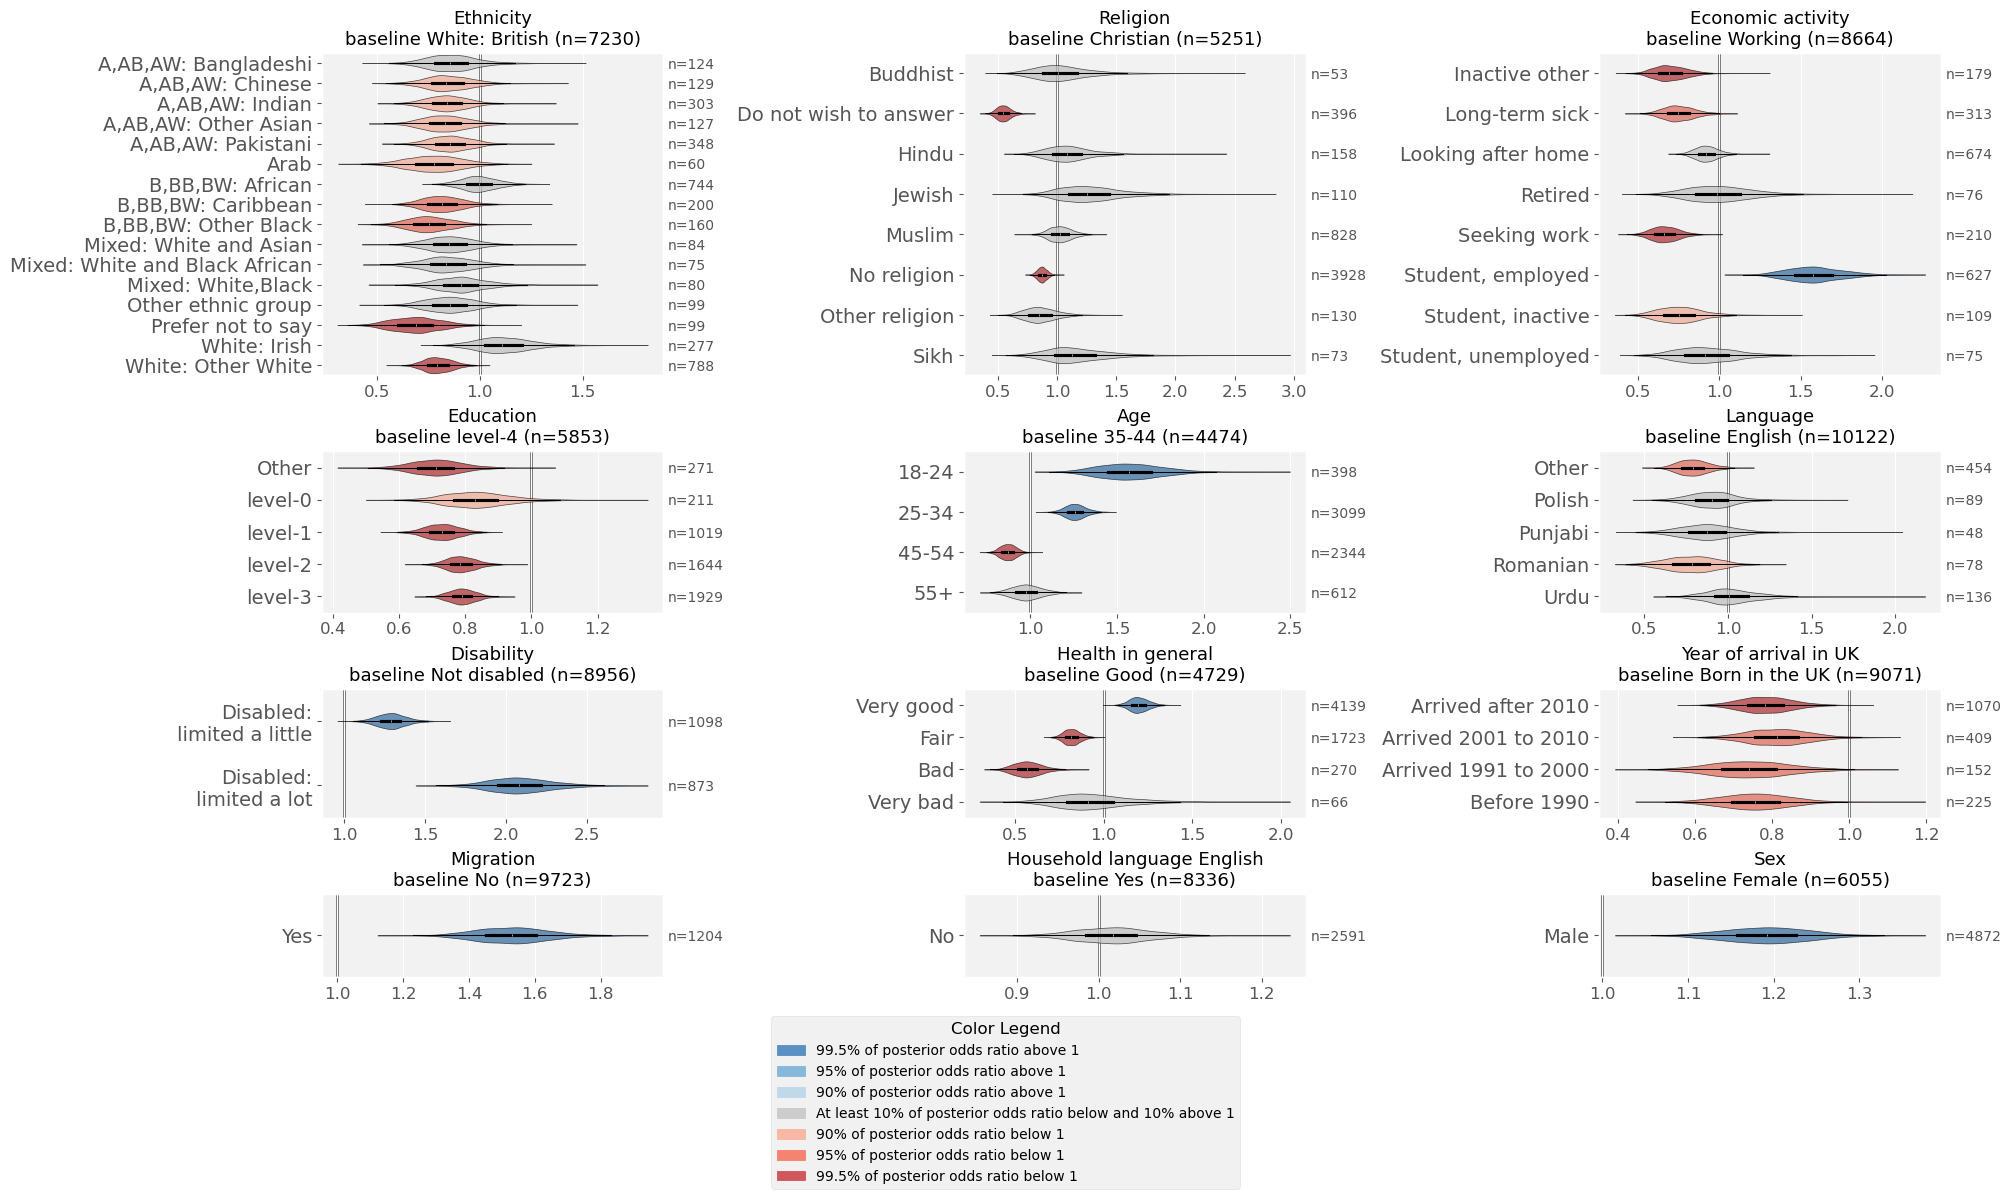

In [11]:

title_var_names = {'AGE': 'Age',
 'SEX': 'Sex',
 'EDU': 'Education',
 'REL': 'Religion',
 'ETH': 'Ethnicity',
 'LAN': 'Language',
 'HHLAN': 'Household language English',
 'MIG': 'Migration',
 'BUK': 'Born in the UK',
 'YUK': 'Year of arrival in UK',
 'HEA': 'Health in general',#'Fair',
 'SCH': 'No',
 'DIS': 'Disability',
 'ENP': 'Enlgish proficieny',
 'EMP': 'Economic activity',}

title_var_names.update(_thinking_and_feeling_description)
title_var_names.update(_social_processes_description)
title_var_names.update(_practical_issues_description)

alpha_besd_backgound = 0.35

baselines = {'AGE': '35-44',
 'SEX': 'Female',
 'EDU': 'level-4',
 'REL': 'Christian',
 'ETH': 'White: British',
 'LAN': 'English',
 'HHLAN': 'Yes',
 'MIG': 'No',
 'BUK': 'Yes',
 'YUK': 'Born in the UK',
 'HEA': 'Good',#'Fair',
 'SCH': 'No',
 'DIS': 'Not disabled',
 'ENP': 'Main language English',
 'EMP': 'Working',
 'besd6' : 'Yes',
 'besd7' : 'Yes',
}

for b in besd_ber:
    baselines[b] = 'Yes'

for b in besd_ord:
    baselines[b] = recode_mapping_reverse[b][0]

plt.style.use('ggplot')

orderd_labels_dict = {}
for var_name in ['ETH','REL','LAN','EMP','EDU','AGE']:
    orderd_labels_dict[var_name] = list( np.sort( list( recode_mapping_for_plot[var_name].values() ) ) )

orderd_labels_dict['YUK'] = ['Born in the UK', 'Arrived after 2010', 'Arrived 2001 to 2010', 'Arrived 1991 to 2000', 'Before 1990' ]
orderd_labels_dict['HEA'] = ['Very good', 'Good', 'Fair', 'Bad', 'Very bad']
orderd_labels_dict['DIS'] = ['Not disabled', 'Disabled:\nlimited a little', 'Disabled:\nlimited a lot']

height_ratios = [7, 3.5, 2.8, 1.8]#[3]*10

fig, axes = plt.subplots(4,3, figsize = (20,10), constrained_layout = True, height_ratios = height_ratios )
for k, (var_name, coef_name) in enumerate( zip(['ETH','REL','EMP', 'EDU','AGE','LAN','DIS','HEA','YUK','MIG','HHLAN','SEX'],
                                              ['beta_eth', 'beta_rel', 'beta_emp', 'beta_edu', 'beta_age', 'beta_lan', 'beta_dis', 'beta_hea', 'beta_yuk','beta_mig', 'beta_hhlan', 'beta_sex']
                                              ) #, 'beta_sch'])
                                         ):
    i,j = k //3, k%3
    ax = axes[i,j]
    h_ratio = height_ratios[i]
    num_violin_plots = len(recode_mapping_reverse[var_name].values()) - 1
    
    if var_name in thinking_and_feeling + social_processes + practical_issues:
        alpha = alpha_violin_plot_besd # 0.85
        _besd_i = 'BeSD' + var_name.strip('besd')
        _title = f'{_besd_i}: {title_var_names[var_name]}\nbaseline {baselines[var_name]}'
    else:
        alpha = alpha_violin_plot_soc # 0.85
        _title = f'{title_var_names[var_name]}\nbaseline {baselines[var_name]}'
    plot_odds_ratio(idata = idata_soc, ax = ax, recode_mapping_reverse = recode_mapping_for_plot, coef_name = coef_name, var_name = var_name, title = _title, num_samples = 2000, 
                    plot_type = 'violin', violin_width = 0.35*(num_violin_plots/h_ratio), max_len_label = 30, baseline = baselines[var_name], survey = survey_bes.copy(), add_n = True, # palette = palette,
                    alpha = alpha, orderd_labels_dict = orderd_labels_dict, title_size = 13 )
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=12)
    if var_name in soc_dems:
        # ax.patch.set_facecolor('whitesmoke')
        ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_besd_backgound) )
    
    if var_name in thinking_and_feeling:
        ax.patch.set_facecolor( _colors_besd['thinking_and_feeling'])
    if var_name in social_processes:
        ax.patch.set_facecolor( _colors_besd['social_processes'])
    if var_name in practical_issues:
        ax.patch.set_facecolor( _colors_besd['practical_issues'])

add_custom_legend(fig, anchor_x = 0.5, anchor_y = -0.2, framealpha = 0.5, fontsize=10, title_fontsize=12, # palette = palette,
                  alpha = alpha_violin_plot_soc) #0.85)

fig.savefig('./fig/ew/soc_odds_ratio.jpg', dpi = 200, bbox_inches='tight')

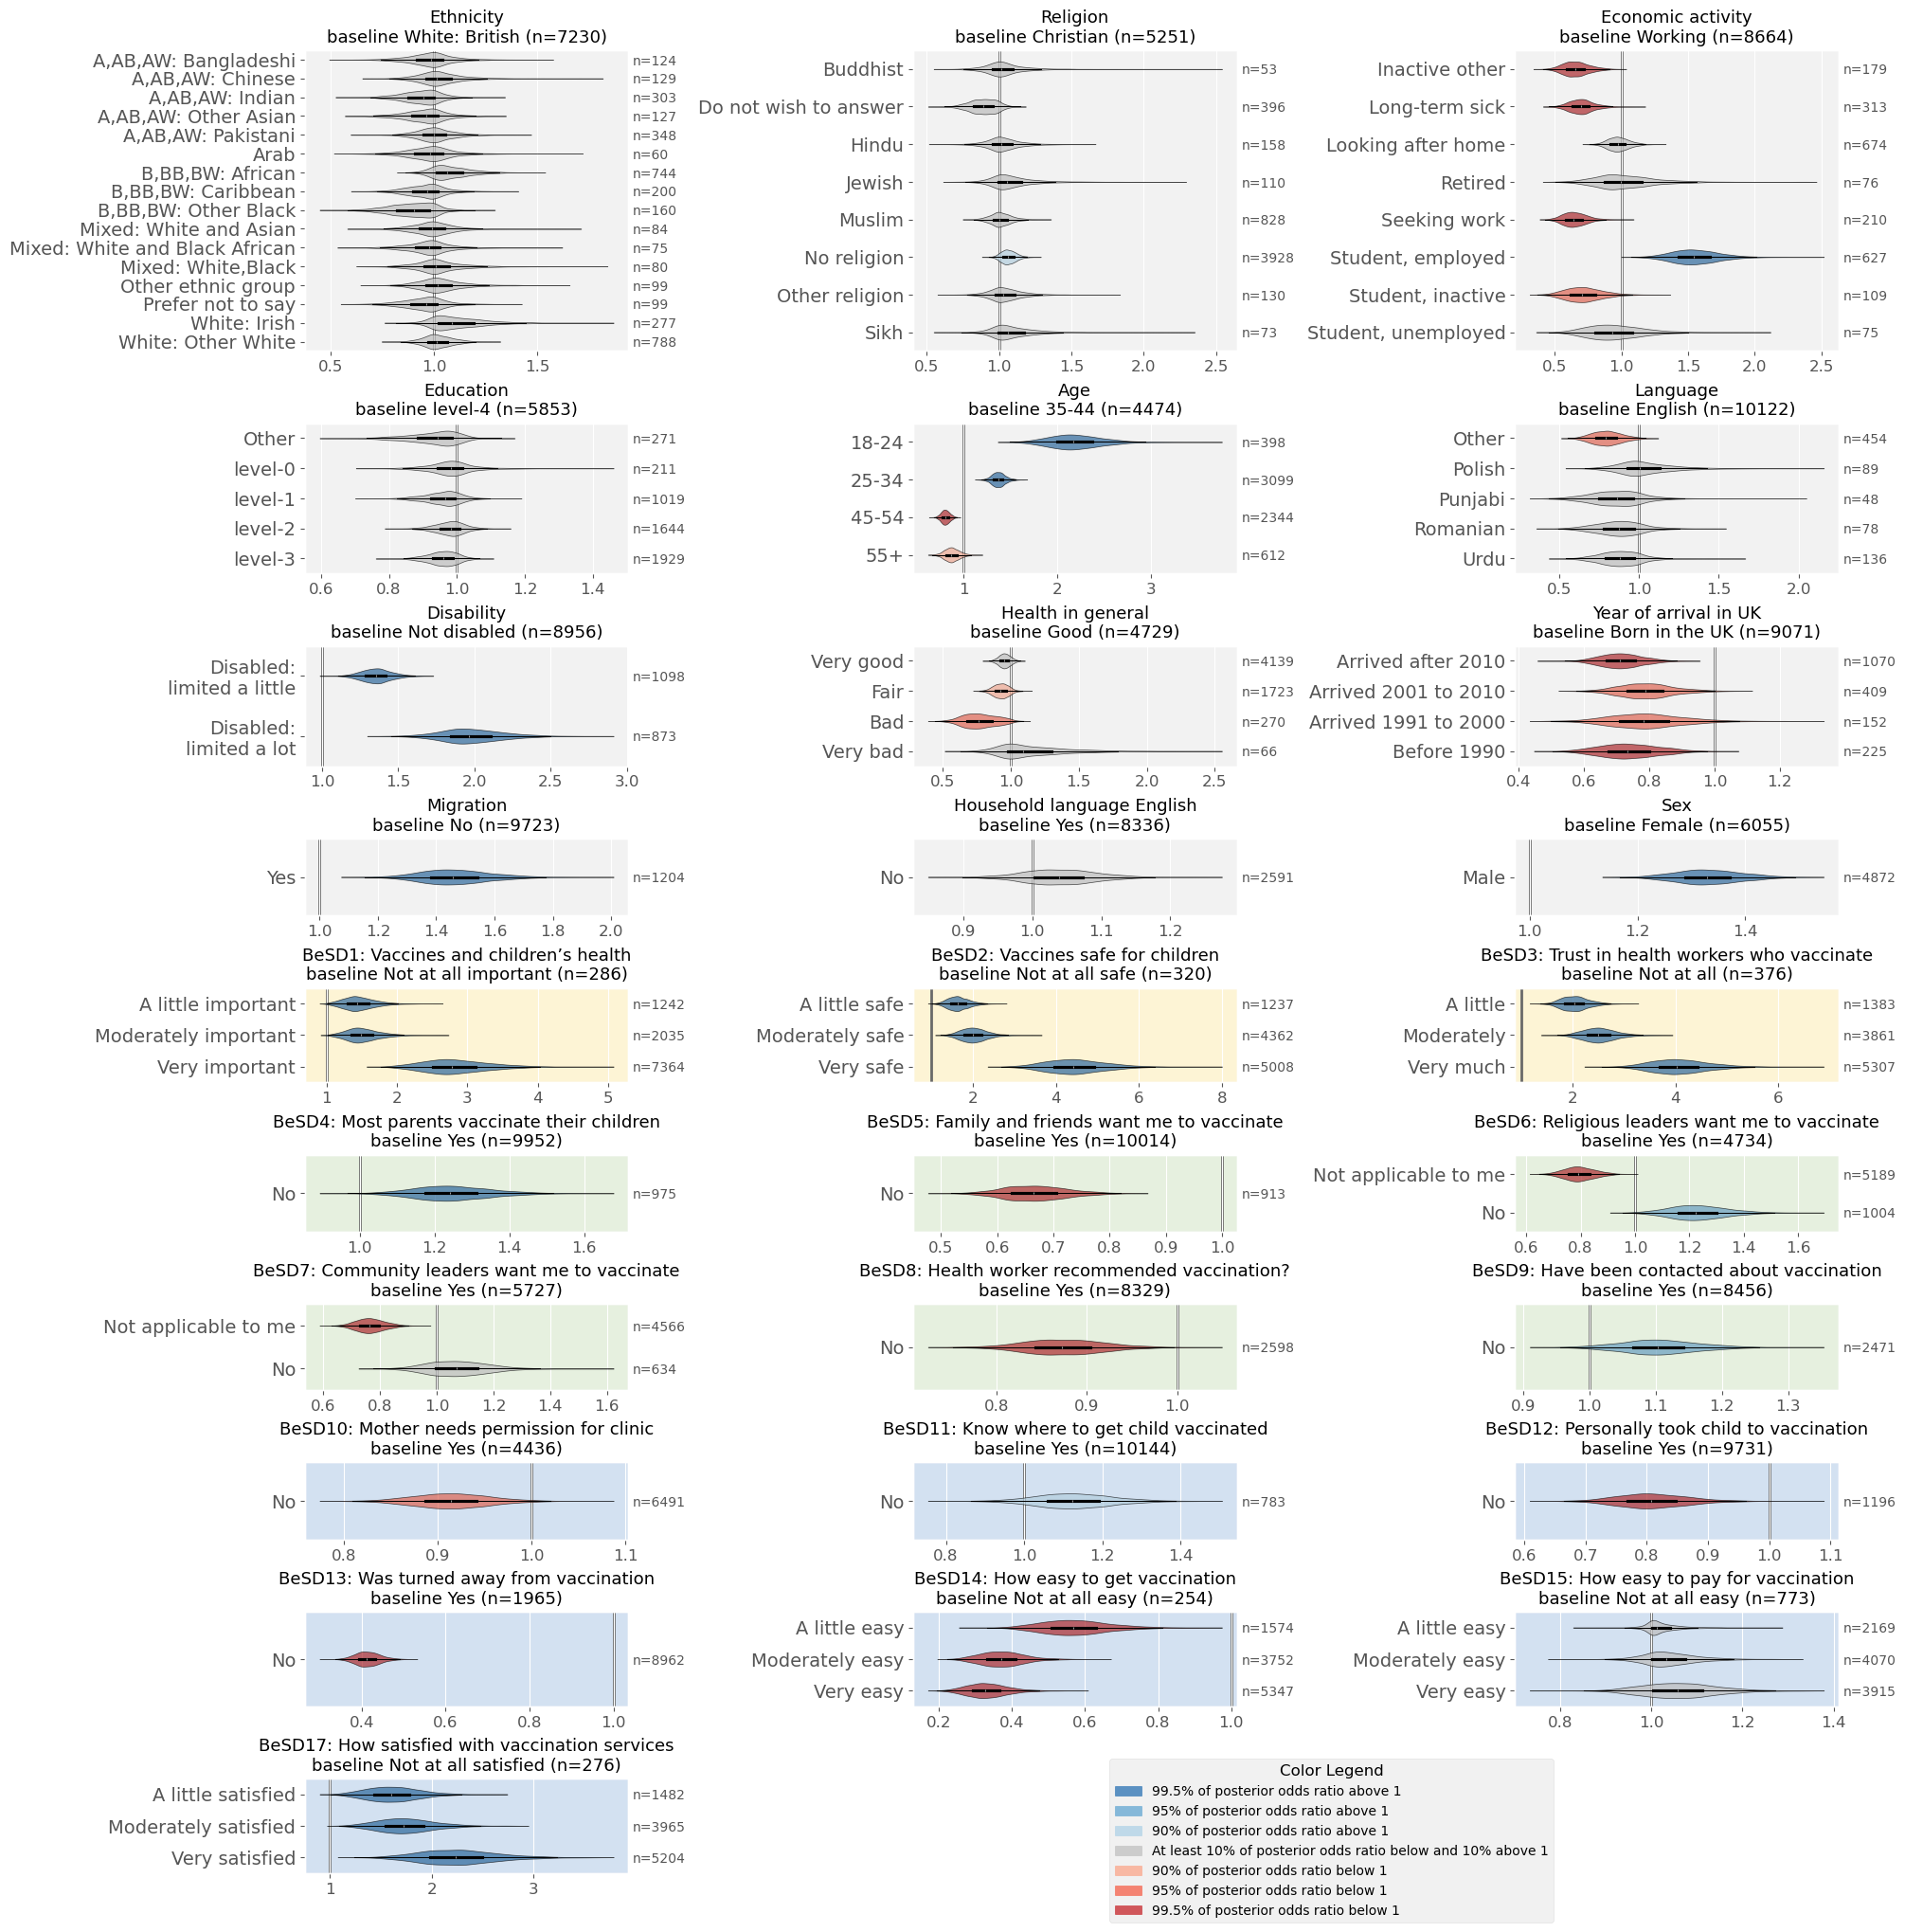

In [12]:

title_var_names = {'AGE': 'Age',
 'SEX': 'Sex',
 'EDU': 'Education',
 'REL': 'Religion',
 'ETH': 'Ethnicity',
 'LAN': 'Language',
 'HHLAN': 'Household language English',
 'MIG': 'Migration',
 'BUK': 'Born in the UK',
 'YUK': 'Year of arrival in UK',
 'HEA': 'Health in general',#'Fair',
 'SCH': 'No',
 'DIS': 'Disability',
 'ENP': 'Enlgish proficieny',
 'EMP': 'Economic activity',}

title_var_names.update(_thinking_and_feeling_description)
title_var_names.update(_social_processes_description)
title_var_names.update(_practical_issues_description)

alpha_besd_backgound = alpha_besd_backgound # 0.35

baselines = {'AGE': '35-44',
 'SEX': 'Female',
 'EDU': 'level-4',
 'REL': 'Christian',
 'ETH': 'White: British',
 'LAN': 'English',
 'HHLAN': 'Yes',
 'MIG': 'No',
 'BUK': 'Yes',
 'YUK': 'Born in the UK',
 'HEA': 'Good',#'Fair',
 'SCH': 'No',
 'DIS': 'Not disabled',
 'ENP': 'Main language English',
 'EMP': 'Working',
 'besd6' : 'Yes',
 'besd7' : 'Yes',
}

for b in besd_ber:
    baselines[b] = 'Yes'

for b in besd_ord:
    baselines[b] = recode_mapping_reverse[b][0]

plt.style.use('ggplot')

orderd_labels_dict = {}
for var_name in ['ETH','REL','LAN','EMP','EDU','AGE']:
    orderd_labels_dict[var_name] = list( np.sort( list( recode_mapping_for_plot[var_name].values() ) ) )

orderd_labels_dict['YUK'] = ['Born in the UK', 'Arrived after 2010', 'Arrived 2001 to 2010', 'Arrived 1991 to 2000', 'Before 1990' ]
orderd_labels_dict['HEA'] = ['Very good', 'Good', 'Fair', 'Bad', 'Very bad']
orderd_labels_dict['DIS'] = ['Not disabled', 'Disabled:\nlimited a little', 'Disabled:\nlimited a lot']

height_ratios = [7, 3.5, 2.8, 1.8, 2.2, 1.8, 2, 1.8, 2.2, 2.2]#[3]*10

fig, axes = plt.subplots(10,3, figsize = (20,20), constrained_layout = True, height_ratios = height_ratios )
for k, (var_name, coef_name) in enumerate( zip(['ETH','REL','EMP', 'EDU','AGE','LAN','DIS','HEA','YUK','MIG','HHLAN','SEX'] + thinking_and_feeling + social_processes + practical_issues,#'SCH'
                                              ['beta_eth', 'beta_rel', 'beta_emp', 'beta_edu', 'beta_age', 'beta_lan', 'beta_dis', 'beta_hea', 'beta_yuk','beta_mig', 'beta_hhlan', 'beta_sex']
                                              + [f'beta_{b}' for b in thinking_and_feeling] + [f'beta_{b}' for b in social_processes] + [f'beta_{b}' for b in practical_issues]) #, 'beta_sch'])
                                         ):
    i,j = k //3, k%3
    ax = axes[i,j]
    h_ratio = height_ratios[i]
    num_violin_plots = len(recode_mapping_reverse[var_name].values()) - 1
    
    if var_name in thinking_and_feeling + social_processes + practical_issues:
        alpha = alpha_violin_plot_besd # 0.85
        _besd_i = 'BeSD' + var_name.strip('besd')
        _title = f'{_besd_i}: {title_var_names[var_name]}\nbaseline {baselines[var_name]}'
    else:
        alpha = alpha_violin_plot_soc # 0.85
        _title = f'{title_var_names[var_name]}\nbaseline {baselines[var_name]}'
    plot_odds_ratio(idata = idata_bes, ax = ax, recode_mapping_reverse = recode_mapping_for_plot, coef_name = coef_name, var_name = var_name, title = _title, num_samples = 2000, 
                    plot_type = 'violin', violin_width = 0.35*(num_violin_plots/h_ratio), max_len_label = 30, baseline = baselines[var_name], survey = survey_bes.copy(), add_n = True,#  palette = palette,
                    alpha = alpha, orderd_labels_dict = orderd_labels_dict, title_size = 13 )
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=12)

    if var_name in soc_dems:
        ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_besd_backgound) )
    if var_name in thinking_and_feeling:
        ax.patch.set_facecolor( _colors_besd['thinking_and_feeling'])
    if var_name in social_processes:
        ax.patch.set_facecolor( _colors_besd['social_processes'])
    if var_name in practical_issues:
        ax.patch.set_facecolor( _colors_besd['practical_issues'])
for k in [28,29]:
    i,j = k //3, k%3
    ax = axes[i,j]
    ax.remove()

add_custom_legend(fig, anchor_x = 0.7, anchor_y = -0.02, framealpha = 0.5, fontsize=10, title_fontsize=12, # palette = palette,
                  alpha = alpha_violin_plot_soc)

fig.savefig('./fig/ew/besd_soc_odds_ratio.jpg', dpi = 200, bbox_inches='tight')